# Matrix Factorisation on Movie Lens 1M dataset
Dataset from: [Movie Lens 1M Dataset](https://grouplens.org/datasets/movielens/1m/)

In [1]:
# Third-party
import numpy as np
from sklearn.metrics import explained_variance_score, mean_squared_error, mean_absolute_error, r2_score

# Local
from Dataset.ml1m_data_loader import load_and_merge_data, ml_test_train_split
from evals.offline_eval_metrics import OfflineSlateEvaluator
from models.matrix_factorisation.NMF_matrix_factorisation import NMFMatrixFactorisation

### Load dataset

In [2]:
df = load_and_merge_data()
df_train, df_test = ml_test_train_split(df, test_proportion=0.2)

In [3]:
df_train.head()

,user_id,movie_id,rating,timestamp,title,genres
0,392,587,1,2000-12-08 19:43:44,Ghost (1990),Comedy|Romance|Thriller
1,1449,2053,1,2000-11-28 18:49:33,"Honey, I Blew Up the Kid (1992)",Children's|Comedy|Sci-Fi
2,2856,1290,3,2000-10-25 20:22:00,Some Kind of Wonderful (1987),Drama|Romance
3,808,2279,3,2000-11-28 06:39:46,Urban Legend (1998),Horror|Thriller
4,4480,2138,4,2000-07-31 06:32:45,Watership Down (1978),Animation|Children's|Drama|Fantasy


### Matrix Factorisation
Matrix factorisation algorithm applied to Top-N and Similarity (by movie) slates.

i.e. answers the questions: "what are the top N movies for a specific user" and "because someone watched a movie, they should watch"


Using:
- [SKLearn NMF (Non-Negative Matrix Factorisation)](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.NMF.html)]
- Similarity code from [here](https://github.com/dinesh-git17/movie_recommendation/tree/main)
- Top-N code from [here](https://medium.com/@quindaly/step-by-step-nmf-example-in-python-9974e38dc9f9)

In [4]:
NMF_model = NMFMatrixFactorisation(df_train, min_ratings=0, n_components=50)

### Evaluation metrics
Offline metrics - adapted from [here](https://github.com/aryan-jadon/Evaluation-Metrics-for-Recommendation-Systems/blob/main/recommenders/evaluation/python_evaluation.py)

Table from [here](https://github.com/recommenders-team/recommenders/blob/main/examples/03_evaluate/evaluation.ipynb)
|Metric|Range|Selection criteria|Limitation|Reference|
|------|-------------------------------|---------|----------|---------|
|RMSE|$> 0$|The smaller the better.|May be biased, and less explainable than MAE|[link](https://en.wikipedia.org/wiki/Root-mean-square_deviation)|
|MAE|$\geq 0$|The smaller the better.|Dependent on variable scale.|[link](https://en.wikipedia.org/wiki/Mean_absolute_error)|
|R2|$\leq 1$|The closer to $1$ the better.|Depend on variable distributions.|[link](https://en.wikipedia.org/wiki/Coefficient_of_determination)|
|Explained variance|$\leq 1$|The closer to $1$ the better.|Depend on variable distributions.|[link](https://en.wikipedia.org/wiki/Explained_variation)|

In [5]:
def evaluation_metrics(y_true, y_pred):
    return {
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "MAE": mean_absolute_error(y_true, y_pred),
        "R Squared": r2_score(y_true, y_pred),
        "Explained variance": explained_variance_score(y_true, y_pred)
    }

In [6]:
# Extract predicted ratings for every movie in df_train
pred_ratings_train = []
for row in df_train.itertuples(index=False):
    pred_ratings_train.append(NMF_model.V.loc[row.user_id][row.title])

In [7]:
# Extract predicted ratings for every movie in df_test
pred_ratings_test = []
for row in df_test.itertuples(index=False):
    pred_ratings_test.append(NMF_model.V.loc[row.user_id][row.title])

In [8]:
print("Metrics on training data:")
[print(f"{k}: {v:.2f}") for k, v in evaluation_metrics(list(df_train.rating), pred_ratings_train).items()]
print("\nMetrics on test data:")
[print(f"{k}: {v:.2f}") for k, v in evaluation_metrics(list(df_test.rating), pred_ratings_test).items()]

Metrics on training data:
RMSE: 2.54
MAE: 2.24
R Squared: -4.18
Explained variance: -0.35

Metrics on test data:
RMSE: 2.76
MAE: 2.48
R Squared: -5.10
Explained variance: -0.26


[None, None, None, None]

In [9]:
# eval = OfflineModelEvaluator()

In [10]:
# y_train = list(df_train.rating)
# y_train_pred = pred_ratings_train
# y_test = list(df_test.rating)
# y_test_pred = pred_ratings_test

In [11]:
# eval.calculate_metrics(y_test, y_test_pred)

### Apply model

In [12]:
recs = NMF_model.movie_similarity("101 Dalmatians (1961)")
recs

Rescuers, The (1977)              0.999389
Aristocats, The (1970)            0.999041
Three Caballeros, The (1945)      0.998768
Bambi (1942)                      0.998292
Fox and the Hound, The (1981)     0.997274
Sword in the Stone, The (1963)    0.997119
Oliver & Company (1988)           0.997047
All Dogs Go to Heaven (1989)      0.996407
Robin Hood (1973)                 0.996228
American Tail, An (1986)          0.996180
Name: 101 Dalmatians (1961), dtype: float64

In [13]:
recs = NMF_model.movie_similarity("101 Dalmatians (1996)")
recs

Homeward Bound II: Lost in San Francisco (1996)    0.990765
George of the Jungle (1997)                        0.986094
Parent Trap, The (1998)                            0.966587
Anastasia (1997)                                   0.955855
Homeward Bound: The Incredible Journey (1993)      0.953707
Madeline (1998)                                    0.948013
American Tail: Fievel Goes West, An (1991)         0.945087
Paulie (1998)                                      0.944268
Casper (1995)                                      0.941548
Tarzan (1999)                                      0.941175
Name: 101 Dalmatians (1996), dtype: float64

In [14]:
recs = NMF_model.movie_similarity("10 Things I Hate About You (1999)")
recs

She's All That (1999)         0.949237
Simply Irresistible (1999)    0.949040
Never Been Kissed (1999)      0.946938
Bachelor, The (1999)          0.934022
Random Hearts (1999)          0.924820
Story of Us, The (1999)       0.909752
Love Letter, The (1999)       0.898975
Mickey Blue Eyes (1999)       0.895375
Drive Me Crazy (1999)         0.893527
Runaway Bride (1999)          0.848550
Name: 10 Things I Hate About You (1999), dtype: float64

In [15]:
recs = NMF_model.movie_similarity("Young Guns (1988)")
recs

Rambo: First Blood Part II (1985)         0.990526
Iron Eagle II (1988)                      0.985025
Iron Eagle (1986)                         0.979768
Braddock: Missing in Action III (1988)    0.969616
Death Wish 4: The Crackdown (1987)        0.961202
Quick and the Dead, The (1995)            0.955094
Last Man Standing (1996)                  0.953669
Rambo III (1988)                          0.951977
Red Dawn (1984)                           0.948652
Aces: Iron Eagle III (1992)               0.945435
Name: Young Guns (1988), dtype: float64

Thoughts:
* Not recommending sequels
* Not using a test-train split -> this algorithm won't work if the requested movie doesn't exist in the pivot table
* Therefore, can't handle new movies or users

## Top-N movies for user

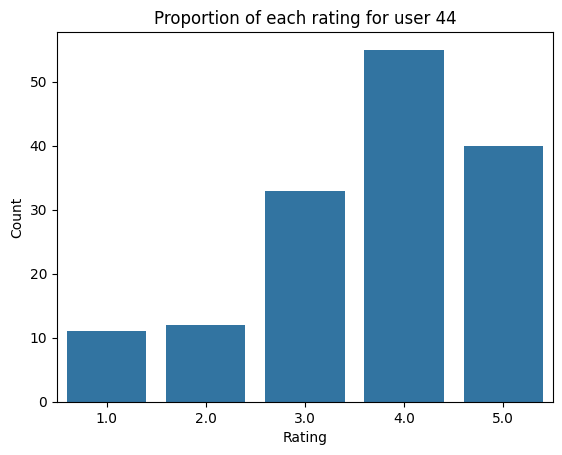

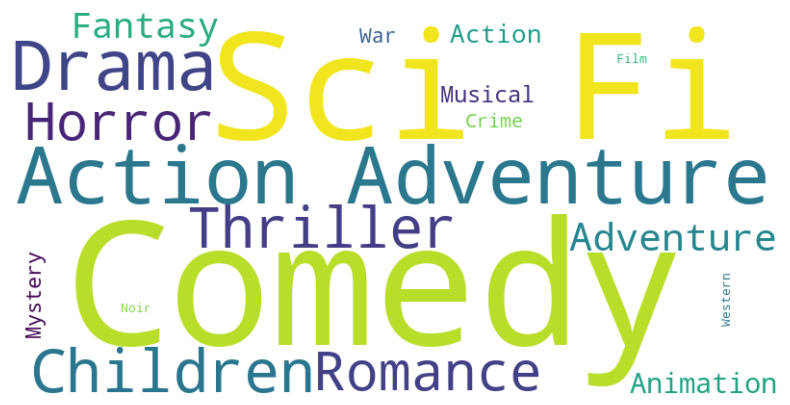

Recommendations for user 44:


,movie_id,title,genres
0,2161,"NeverEnding Story, The (1984)","[Adventure, Children's, Fantasy]"
1,2797,Big (1988),"[Comedy, Fantasy]"
2,589,Terminator 2: Judgment Day (1991),"[Action, Sci-Fi, Thriller]"
3,2005,"Goonies, The (1985)","[Adventure, Children's, Fantasy]"
4,3114,Toy Story 2 (1999),"[Animation, Children's, Comedy]"
5,919,"Wizard of Oz, The (1939)","[Adventure, Children's, Drama, Musical]"
6,720,Wallace & Gromit: The Best of Aardman Animatio...,[Animation]
7,457,"Fugitive, The (1993)","[Action, Thriller]"
8,1080,Monty Python's Life of Brian (1979),[Comedy]
9,2804,"Christmas Story, A (1983)","[Comedy, Drama]"


In [16]:
user_id  = 44
NMF_model.understand_user_profile(user_id)
rec = NMF_model.user_top_N(user_id)
print(f"Recommendations for user 44:")
rec_df = NMF_model.get_recommend_dataframe(rec)
display(rec_df)

In [17]:
rec_ids = rec_df["movie_id"]
eval = OfflineSlateEvaluator(rec_ids, df_test, user_id, 3.5)

In [18]:
[print(f"{k}: {v:.2f}") for k, v in eval.calculate_metrics(k=10).items()]

precision_at_k: 0.30
recall_at_k: 0.12
f1@k: 0.17
ndcg_at_k: 0.70
intra_list_similarity: 0.00


[None, None, None, None, None]

## User profile evaluation

In [ ]:
user_ids = [6013, 2195, 1198, 3662, 4713]

In [ ]:
for user_id in user_ids:
    NMF_model.understand_user_profile(user_id, rating_dist=False, wc=False)
    rec = NMF_model.user_top_N(user_id)
    print(f"Recommendations for user {user_id}")
    display(NMF_model.get_recommend_dataframe(rec))